In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from data.simulations import (
    c1_chain,
    c2_fork,
    c3_unobserved_feature_confounder,
    c4_observed_feature_confounder,
    c5_collider,
    c6_unobserved_prediction_confounder,
)
from shapley_values.causal_shap_paper import CausalExplainer, EffectType
from shapley_values.utils import get_baseline
import numpy as np
import xgboost
import shap

/Users/maksym/Documents/Files/Heavy/Studing/thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Causal Shapley on canonical structures (C1–C6)

## C1 — Chain

Baseline Value (E[f(X)]):  1.0042182
Predicted Value (f(x))  [2.006796]
Shapley Values + (E[f(X)]):  2.007


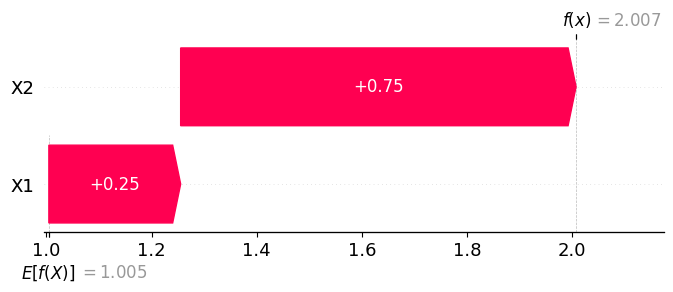

In [2]:
X, y = c1_chain(num_samples=10000)
sample = np.array([1, 2])
model = xgboost.XGBRegressor()
model.fit(X, y)

X = np.vstack([X, sample])
y = np.append(y, model.predict([sample]))

feature_names = ["X1", "X2"]
# C1 chain: X1 -> X2.  Two tiers, no hidden confounding.
causal_model = [[0], [1]]
confounding = [False, False]

explainer = CausalExplainer(X=X, model=model, is_classification=False, rounding_precision=1, feature_names=feature_names)
phis = explainer.compute_shapley_values(
    sample,
    effect_type=EffectType.TOTAL,
    causal_model=causal_model,
    confounding=confounding,
)

explanation = shap.Explanation(values=np.array(phis), feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

## C2 — Fork

Baseline Value (E[f(X)]):  0.5042781
Predicted Value (f(x))  [1.5005155]
Shapley Values + (E[f(X)]):  1.501


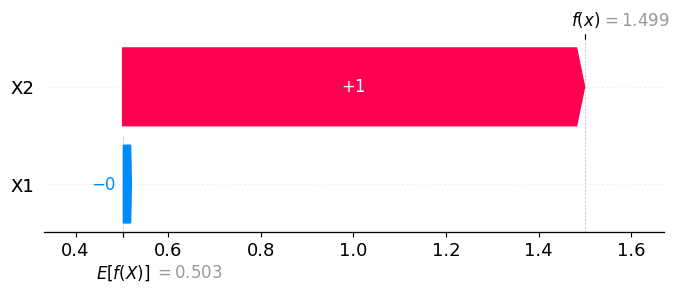

In [3]:
X, y = c2_fork(num_samples=10000)
sample = np.array([2.5, 1.5])
model = xgboost.XGBRegressor()
model.fit(X, y)

X = np.vstack([X, sample])
y = np.append(y, model.predict([sample]))

feature_names = ["X1", "X2"]
# C2 fork: X2 -> X1.  X2 (index 1) is upstream, X1 (index 0) downstream.
causal_model = [[1], [0]]
confounding = [False, False]

explainer = CausalExplainer(X=X, model=model, is_classification=False, rounding_precision=1, feature_names=feature_names)
phis = explainer.compute_shapley_values(
    sample,
    effect_type=EffectType.TOTAL,
    causal_model=causal_model,
    confounding=confounding,
)

explanation = shap.Explanation(values=np.array(phis), feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

## C3 — Unobserved feature confounder

Baseline Value (E[f(X)]):  1.0054532
Predicted Value (f(x))  [2.0019894]
Shapley Values + (E[f(X)]):  2.002


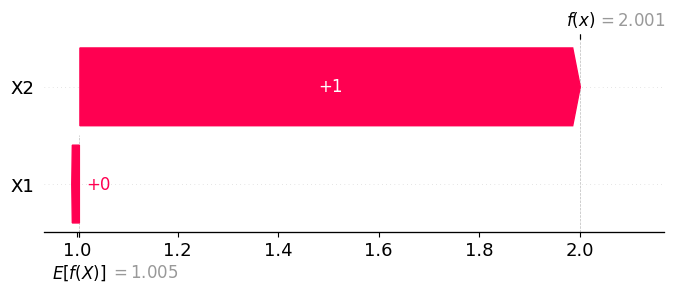

In [4]:
X, y = c3_unobserved_feature_confounder(num_samples=10000)
sample = np.array([2, 2])
model = xgboost.XGBRegressor()
model.fit(X, y)

X = np.vstack([X, sample])
y = np.append(y, model.predict([sample]))

feature_names = ["X1", "X2"]
# C3 unobserved feature confounder: X1 and X2 share hidden parent X3.
# One tier with both features, marked as confounded.
causal_model = [[0, 1]]
confounding = [True]

explainer = CausalExplainer(X=X, model=model, is_classification=False, rounding_precision=1, feature_names=feature_names)
phis = explainer.compute_shapley_values(
    sample,
    effect_type=EffectType.TOTAL,
    causal_model=causal_model,
    confounding=confounding,
)

explanation = shap.Explanation(values=np.array(phis), feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

## C4 — Observed feature confounder

Baseline Value (E[f(X)]):  1.0059167
Predicted Value (f(x))  [2.0016055]
Shapley Values + (E[f(X)]):  2.002


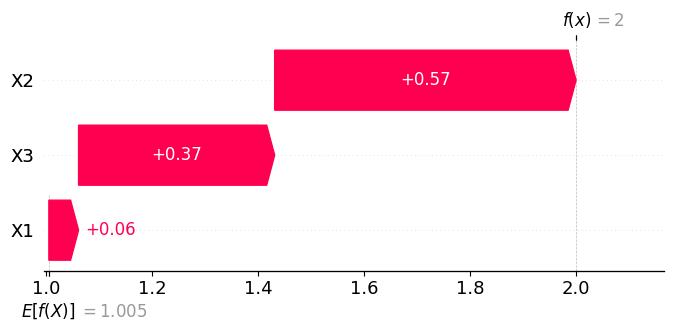

In [5]:
X, y = c4_observed_feature_confounder(num_samples=10000)
sample = np.array([2, 2, 1])
model = xgboost.XGBRegressor()
model.fit(X, y)

X = np.vstack([X, sample])
y = np.append(y, model.predict([sample]))

feature_names = ["X1", "X2", "X3"]
# C4 observed feature confounder: X3 -> X1, X3 -> X2.
# Tier 1: X3 (index 2). Tier 2: X1, X2 (indices 0, 1) — same level, no edge between them.
causal_model = [[2], [0, 1]]
confounding = [False, False]

explainer = CausalExplainer(X=X, model=model, is_classification=False, rounding_precision=1, feature_names=feature_names)
phis = explainer.compute_shapley_values(
    sample,
    effect_type=EffectType.TOTAL,
    causal_model=causal_model,
    confounding=confounding,
)

explanation = shap.Explanation(values=np.array(phis), feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

## C5 — Collider

Baseline Value (E[f(X)]):  2.0106077
Predicted Value (f(x))  [2.997673]
Shapley Values + (E[f(X)]):  2.998


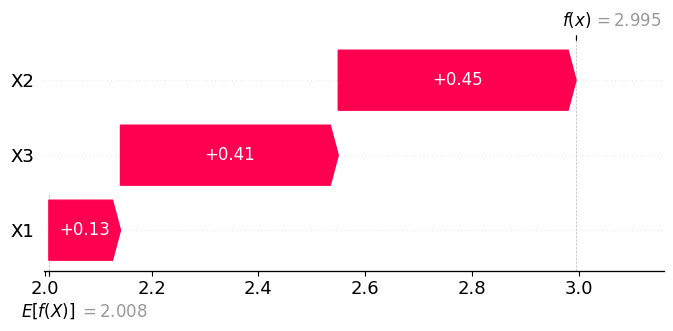

In [6]:
X, y = c5_collider(num_samples=10000)
sample = np.array([0.75, 0.75, 2.25])
model = xgboost.XGBRegressor()
model.fit(X, y)

X = np.vstack([X, sample])
y = np.append(y, model.predict([sample]))

feature_names = ["X1", "X2", "X3"]
# C5 collider: X1 -> X3, X2 -> X3.
# Tier 1: X1, X2 (indices 0, 1) — independent parents. Tier 2: X3 (index 2).
causal_model = [[0, 1], [2]]
confounding = [False, False]

explainer = CausalExplainer(X=X, model=model, is_classification=False, rounding_precision=1, feature_names=feature_names)
phis = explainer.compute_shapley_values(
    sample,
    effect_type=EffectType.TOTAL,
    causal_model=causal_model,
    confounding=confounding,
)

explanation = shap.Explanation(values=np.array(phis), feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)

## C6 — Unobserved prediction confounder

Baseline Value (E[f(X)]):  1.0161127
Predicted Value (f(x))  [2.204472]
Shapley Values + (E[f(X)]):  2.204


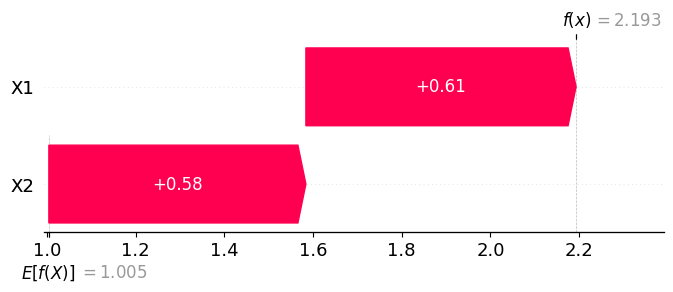

In [7]:
X, y = c6_unobserved_prediction_confounder(num_samples=10000)
sample = np.array([2, 1])
model = xgboost.XGBRegressor()
model.fit(X, y)

X = np.vstack([X, sample])
y = np.append(y, model.predict([sample]))

feature_names = ["X1", "X2"]
# C6 unobserved prediction confounder: X3 -> X1 (X3 hidden), X3 -> Y, X2 -> Y.
# X1 and X2 are causally unrelated to each other and have no shared hidden parent.
causal_model = [[0, 1]]
confounding = [False]

explainer = CausalExplainer(X=X, model=model, is_classification=False, rounding_precision=1, feature_names=feature_names)
phis = explainer.compute_shapley_values(
    sample,
    effect_type=EffectType.TOTAL,
    causal_model=causal_model,
    confounding=confounding,
)

explanation = shap.Explanation(values=np.array(phis), feature_names=feature_names,
                               base_values=get_baseline(X, model), output_names=['Prediction'])
shap.plots.waterfall(explanation)